# Clasificación de enfermedades en hojas de plantas (PlantVillage)
## Parte 1 · Análisis exploratorio (EDA) y data augmentation

**Visión por Computadora II · CEIA · FIUBA**

Objetivos de este notebook:
1. Conocer el dataset: clases, desbalance, especies, propiedades de las imágenes.
2. Detectar problemas que afecten la evaluación (duplicados, fuga de datos entre splits).
3. Definir un split estratificado **reproducible** que usará todo el equipo.
4. Definir y visualizar el pipeline de data augmentation.

> Las decisiones de este notebook (split, tamaño de imagen, normalización, transforms) quedan guardadas en `splits/` y en la sección final para que los notebooks de modelos las reutilicen.

## 0. Configuración

In [1]:
import os, random, hashlib, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Carpeta con una subcarpeta por clase (PlantVillage de Kaggle, 13 clases).
# Se puede sobreescribir con la variable de entorno PV_DATA_DIR.
DATA_DIR = Path(os.environ.get("PV_DATA_DIR", "../PlantVillage")).resolve()
SPLITS_DIR = Path("../splits"); SPLITS_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("../cache"); CACHE_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224          # entrada estándar de los modelos preentrenados en ImageNet
IMG_EXTS = {".jpg", ".jpeg", ".png"}
sns.set_theme(style="whitegrid")
print("Dataset en:", DATA_DIR, "| existe:", DATA_DIR.exists())
print("torch", torch.__version__, "| GPU:", torch.cuda.is_available())

C:\CEIA\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset en: C:\CEIA\VpC2\PlantVillage | existe: True
torch 2.14.0+cpu | GPU: False


## 1. Inventario del dataset

Cada carpeta es una clase. Los nombres no son 100 % consistentes (`Tomato_Bacterial_spot`, `Tomato__Target_Spot`, `Pepper__bell___healthy`), así que extraemos la especie (primera palabra) y la condición (el resto) con una expresión regular. Una hoja es `healthy` o tiene una enfermedad.

In [2]:
records = []
for cls_dir in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    for f in cls_dir.iterdir():
        if f.suffix.lower() in IMG_EXTS:
            records.append((str(f.relative_to(DATA_DIR)), cls_dir.name))

df = pd.DataFrame(records, columns=["relpath", "label"])
parts = df["label"].str.replace("Pepper__bell", "Pepper", regex=False).str.extract(r"^([A-Za-z]+)_+(.*)$")
df["plant"] = parts[0]
df["condition"] = parts[1].str.replace("_", " ").str.strip()
df["healthy"] = df["condition"].str.lower().eq("healthy")

classes = sorted(df["label"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df["y"] = df["label"].map(class_to_idx)

print(f"Imágenes: {len(df):,} | Clases: {len(classes)} | Especies: {df['plant'].nunique()}")
print(f"Sanas: {df['healthy'].sum():,} ({df['healthy'].mean():.1%}) | Enfermas: {(~df['healthy']).sum():,}")
df.head()

Imágenes: 20,638 | Clases: 15 | Especies: 3
Sanas: 3,221 (15.6%) | Enfermas: 17,417


,relpath,label,plant,condition,healthy,y
0,Pepper__bell___Bacterial_spot\0022d6b7-d47c-4e...,Pepper__bell___Bacterial_spot,Pepper,Bacterial spot,False,0
1,Pepper__bell___Bacterial_spot\006adb74-934f-44...,Pepper__bell___Bacterial_spot,Pepper,Bacterial spot,False,0
2,Pepper__bell___Bacterial_spot\00f2e69a-1e56-41...,Pepper__bell___Bacterial_spot,Pepper,Bacterial spot,False,0
3,Pepper__bell___Bacterial_spot\01613cd0-d3cd-4e...,Pepper__bell___Bacterial_spot,Pepper,Bacterial spot,False,0
4,Pepper__bell___Bacterial_spot\0169b9ac-07b9-4b...,Pepper__bell___Bacterial_spot,Pepper,Bacterial spot,False,0


## 2. Distribución de clases

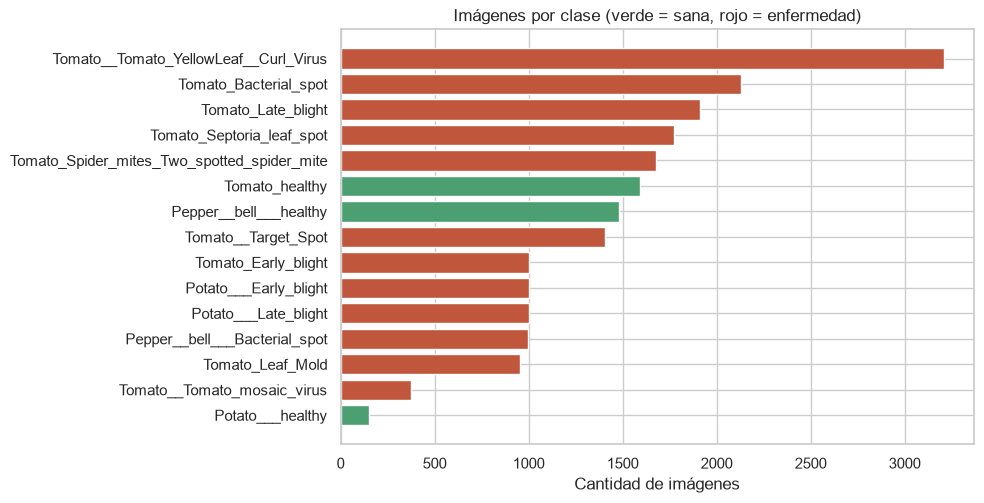

Clase mayoritaria: Tomato__Tomato_YellowLeaf__Curl_Virus (3208)
Clase minoritaria: Potato___healthy (152)
Ratio de desbalance (max/min): 21.1x


In [3]:
counts = df["label"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 0.28 * len(counts) + 1))
colors = ["#4c9f70" if "healthy" in c.lower() else "#c0563b" for c in counts.index]
ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel("Cantidad de imágenes"); ax.set_title("Imágenes por clase (verde = sana, rojo = enfermedad)")
plt.tight_layout(); plt.show()

print(f"Clase mayoritaria: {counts.idxmax()} ({counts.max()})")
print(f"Clase minoritaria: {counts.idxmin()} ({counts.min()})")
print(f"Ratio de desbalance (max/min): {counts.max() / counts.min():.1f}x")

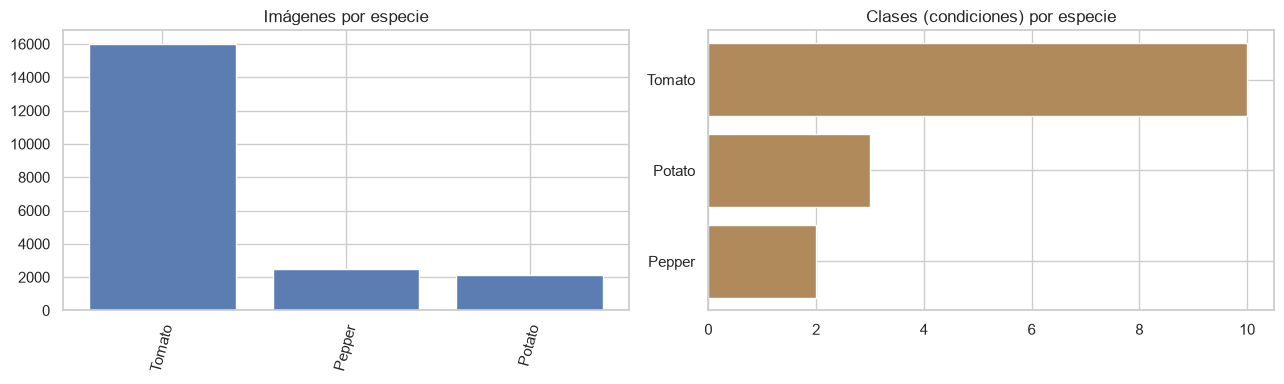

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plant_counts = df["plant"].value_counts()
axes[0].bar(plant_counts.index, plant_counts.values, color="#5b7db1")
axes[0].set_title("Imágenes por especie"); axes[0].tick_params(axis="x", rotation=75)

per_plant = df.groupby("plant").agg(n_clases=("label", "nunique"), n_img=("label", "size")).sort_values("n_clases")
axes[1].barh(per_plant.index, per_plant["n_clases"], color="#b18a5b")
axes[1].set_title("Clases (condiciones) por especie")
plt.tight_layout(); plt.show()

**Observaciones a completar por el equipo:** ¿el desbalance justifica ponderar la loss o muestrear por clase? ¿Hay especies con una sola condición (donde "enfermedad" e "identidad de la especie" pueden confundirse)?

## 3. Propiedades de las imágenes

Leemos solo el encabezado de cada archivo (rápido) para obtener resolución, modo de color y formato.

In [5]:
def img_meta(relpath):
    with Image.open(DATA_DIR / relpath) as im:
        return im.size[0], im.size[1], im.mode, im.format

meta_cache = CACHE_DIR / "img_meta.csv"
if meta_cache.exists():
    meta = pd.read_csv(meta_cache)
else:
    rows = [img_meta(p) for p in tqdm(df["relpath"], desc="Metadatos")]
    meta = pd.DataFrame(rows, columns=["w", "h", "mode", "format"])
    meta.to_csv(meta_cache, index=False)

for c in ["w", "h", "mode", "format"]:
    df[c] = meta[c].values
print(df[["w", "h"]].describe().loc[["min", "max", "mean"]].round(1))
print("\nModos de color:", df["mode"].value_counts().to_dict())
print("Formatos:", df["format"].value_counts().to_dict())
print("Resoluciones distintas:", df.groupby(["w", "h"]).ngroups)
print("Imágenes no cuadradas:", int((df["w"] != df["h"]).sum()))

Metadatos:   0%|          | 0/20638 [00:00<?, ?it/s]

Metadatos:   0%|          | 20/20638 [00:00<01:44, 197.06it/s]

Metadatos:   0%|          | 40/20638 [00:00<01:43, 198.50it/s]

Metadatos:   0%|          | 62/20638 [00:00<01:46, 193.73it/s]

Metadatos:   0%|          | 82/20638 [00:00<01:46, 192.80it/s]

...

Metadatos: 100%|█████████▉| 20590/20638 [02:04<00:00, 182.07it/s]

Metadatos: 100%|█████████▉| 20609/20638 [02:04<00:00, 184.14it/s]

Metadatos: 100%|█████████▉| 20628/20638 [02:04<00:00, 177.23it/s]

Metadatos: 100%|██████████| 20638/20638 [02:04<00:00, 165.57it/s]

          w      h
min   256.0  256.0
max   256.0  256.0
mean  256.0  256.0

Modos de color: {'RGB': 20637, 'RGBA': 1}
Formatos: {'JPEG': 20637, 'PNG': 1}
Resoluciones distintas: 1
Imágenes no cuadradas: 0


Si todas las imágenes tienen la misma resolución (en PlantVillage suele ser 256×256), no hace falta lidiar con relaciones de aspecto: el cambio a 224×224 es un simple resize/crop.

## 4. Muestras visuales por clase

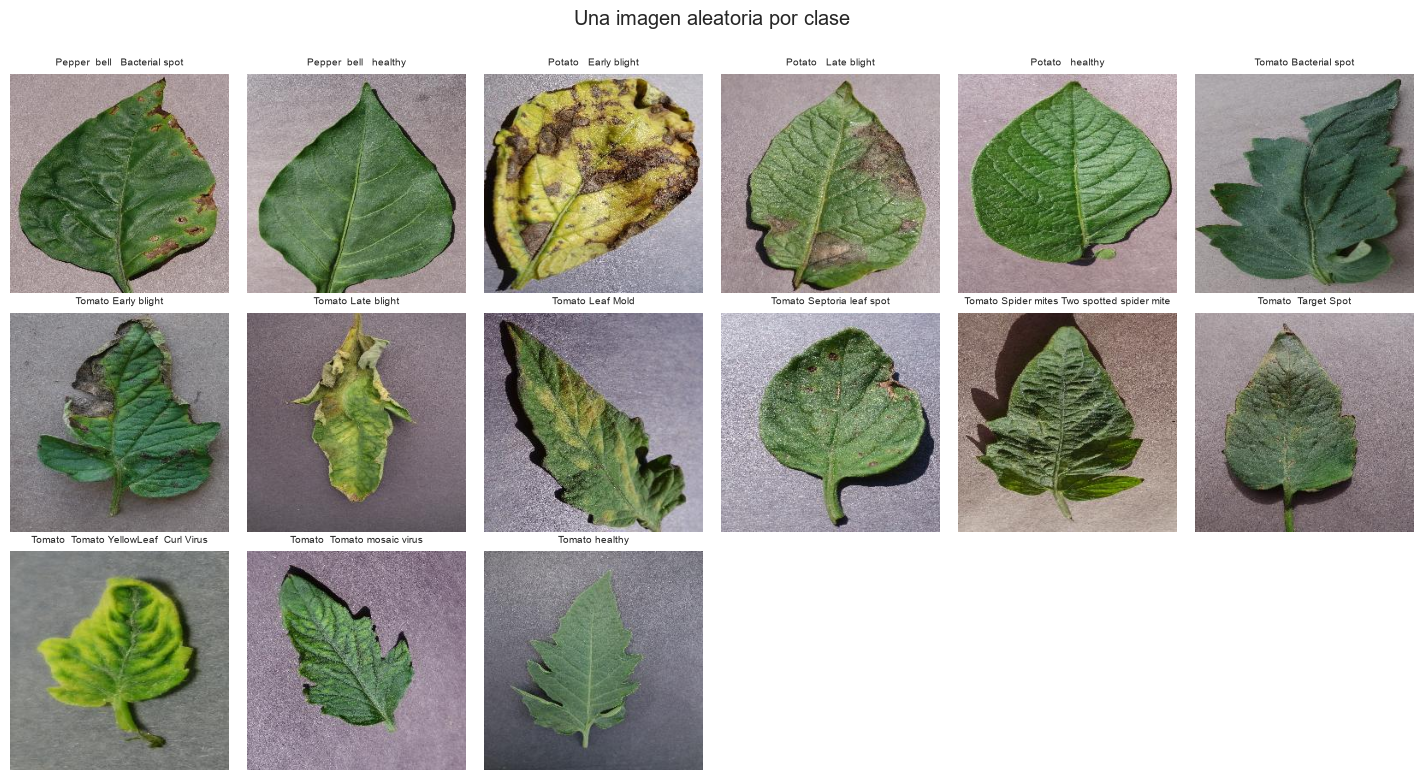

In [6]:
def show_grid(df_, n_cols=6, per_class=1, seed=SEED, title=None):
    rng = np.random.RandomState(seed)
    labels = sorted(df_["label"].unique())
    n_rows = int(np.ceil(len(labels) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 2.6 * n_rows))
    for ax in np.ravel(axes): ax.axis("off")
    for ax, lab in zip(np.ravel(axes), labels):
        row = df_[df_["label"] == lab].sample(per_class, random_state=rng).iloc[0]
        ax.imshow(Image.open(DATA_DIR / row["relpath"]).convert("RGB"))
        ax.set_title(" ".join(lab.split("_")).strip(), fontsize=7, wrap=True)
    if title: fig.suptitle(title, y=1.0)
    plt.tight_layout(); plt.show()

show_grid(df, title="Una imagen aleatoria por clase")

**Qué mirar:** fondo (¿uniforme, gris, de laboratorio?), centrado y tamaño de la hoja, iluminación, y qué tan parecidas se ven las enfermedades de una misma especie. Esto anticipa qué clases se confundirán y por qué la robustez ante fondos reales será un problema.

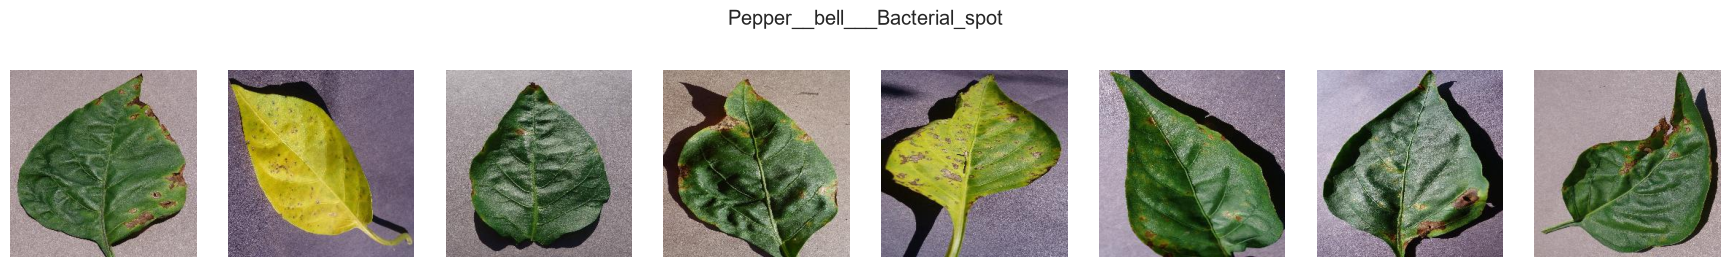

In [7]:
# Variabilidad intra-clase: 8 imágenes de una misma clase
def show_class(label, n=8):
    sub = df[df["label"] == label].sample(n, random_state=SEED)
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.6))
    for ax, (_, r) in zip(axes, sub.iterrows()):
        ax.imshow(Image.open(DATA_DIR / r["relpath"]).convert("RGB")); ax.axis("off")
    fig.suptitle(label, y=1.02); plt.tight_layout(); plt.show()

show_class(classes[0])

## 5. Color e iluminación

Calculamos media y desvío por canal sobre una muestra (para decidir la normalización) y la distribución de brillo por clase (para saber cuánta variación de iluminación existe realmente en el dataset).

In [8]:
N_PER_CLASS = 40
sample = df.sample(frac=1, random_state=SEED).groupby("label").head(N_PER_CLASS).reset_index(drop=True)

pix_sum, pix_sq, n_pix, brightness = np.zeros(3), np.zeros(3), 0, []
for p in tqdm(sample["relpath"], desc="Estadísticas de color"):
    a = np.asarray(Image.open(DATA_DIR / p).convert("RGB").resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255
    pix_sum += a.sum((0, 1)); pix_sq += (a ** 2).sum((0, 1)); n_pix += a.shape[0] * a.shape[1]
    brightness.append(a.mean())

pv_mean = pix_sum / n_pix
pv_std = np.sqrt(pix_sq / n_pix - pv_mean ** 2)
sample["brightness"] = brightness
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
print("PlantVillage  mean:", pv_mean.round(3), "std:", pv_std.round(3))
print("ImageNet      mean:", IMAGENET_MEAN, "std:", IMAGENET_STD)

Estadísticas de color:   0%|          | 0/600 [00:00<?, ?it/s]

Estadísticas de color:   6%|▌         | 36/600 [00:00<00:01, 320.90it/s]

Estadísticas de color:  12%|█▏        | 71/600 [00:00<00:01, 330.53it/s]

Estadísticas de color:  18%|█▊        | 105/600 [00:00<00:01, 272.03it/s]

Estadísticas de color:  23%|██▎       | 138/600 [00:00<00:01, 290.92it/s]

...

Estadísticas de color:  86%|████████▌ | 515/600 [00:01<00:00, 260.96it/s]

Estadísticas de color:  91%|█████████▏| 548/600 [00:01<00:00, 276.30it/s]

Estadísticas de color:  97%|█████████▋| 581/600 [00:02<00:00, 287.07it/s]

Estadísticas de color: 100%|██████████| 600/600 [00:02<00:00, 283.90it/s]

PlantVillage  mean: [0.463 0.479 0.421] std: [0.189 0.163 0.202]
ImageNet      mean: [0.485, 0.456, 0.406] std: [0.229, 0.224, 0.225]


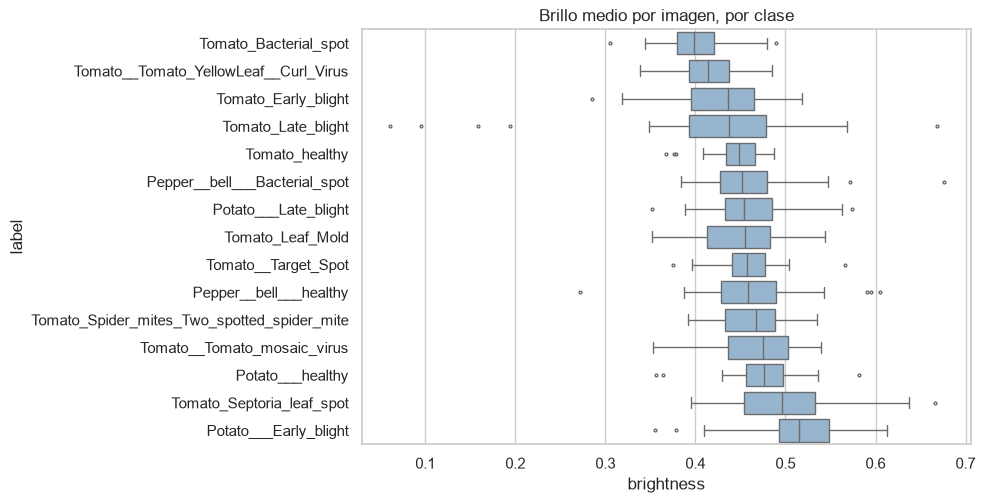

Rango global de brillo: 0.06 - 0.68


In [9]:
order = sample.groupby("label")["brightness"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 0.28 * len(order) + 1))
sns.boxplot(data=sample, y="label", x="brightness", order=order, color="#8fb5d9", ax=ax, fliersize=2)
ax.set_title("Brillo medio por imagen, por clase"); plt.tight_layout(); plt.show()
print("Rango global de brillo: %.2f - %.2f" % (sample.brightness.min(), sample.brightness.max()))

**Decisión:** usamos la normalización de ImageNet (`IMAGENET_MEAN/STD`) porque los modelos preentrenados fueron entrenados con ella; las estadísticas propias de PlantVillage se calculan solo como referencia.

## 6. Duplicados y riesgo de fuga de datos (data leakage)

PlantVillage tiene un problema conocido: varias imágenes provienen de **la misma hoja** fotografiada/rotada de distintas formas. Si un par casi idéntico cae en train y test, el accuracy queda inflado. Buscamos:
- **Duplicados exactos** (hash MD5 del archivo).
- **Casi-duplicados** (hash perceptual dHash de 64 bits, con distancia de Hamming baja).

In [10]:
def dhash(path, size=8):
    with Image.open(path) as im:
        im.draft("L", (size * 8, size * 8))            # decodificación JPEG rápida
        g = np.asarray(im.convert("L").resize((size + 1, size), Image.LANCZOS), dtype=np.int16)
    bits = (g[:, 1:] > g[:, :-1]).flatten()
    return int("".join("1" if b else "0" for b in bits), 2)

def md5(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()

hash_cache = CACHE_DIR / "hashes.csv"
if hash_cache.exists():
    hashes = pd.read_csv(hash_cache, dtype={"dhash": str})
else:
    rows = []
    for p in tqdm(df["relpath"], desc="Hashes"):
        fp = DATA_DIR / p
        rows.append((md5(fp), str(dhash(fp))))
    hashes = pd.DataFrame(rows, columns=["md5", "dhash"]); hashes.to_csv(hash_cache, index=False)

df["md5"] = hashes["md5"].values
df["dhash"] = hashes["dhash"].astype(object).map(int).values
exact = df[df.duplicated("md5", keep=False)]
print(f"Imágenes con duplicado exacto: {len(exact)} en {exact['md5'].nunique()} grupos")
print("Grupos con etiquetas distintas:", int((exact.groupby("md5")["label"].nunique() > 1).sum()))

Hashes:   0%|          | 0/20638 [00:00<?, ?it/s]

Hashes:   0%|          | 101/20638 [00:00<00:20, 1006.18it/s]

Hashes:   1%|          | 227/20638 [00:00<00:17, 1147.76it/s]

Hashes:   2%|▏         | 347/20638 [00:00<00:17, 1166.95it/s]

Hashes:   2%|▏         | 482/20638 [00:00<00:16, 1235.34it/s]

...

Hashes:  98%|█████████▊| 20293/20638 [00:16<00:00, 1117.84it/s]

Hashes:  99%|█████████▉| 20406/20638 [00:16<00:00, 920.18it/s] 

Hashes:  99%|█████████▉| 20516/20638 [00:16<00:00, 954.62it/s]

Hashes: 100%|██████████| 20638/20638 [00:16<00:00, 1255.24it/s]

Imágenes con duplicado exacto: 28 en 14 grupos
Grupos con etiquetas distintas: 0


Imágenes con dHash idéntico a otra: 28 (0.1%) en 14 grupos
Grupos con etiquetas distintas (posible ruido de etiquetas): 0


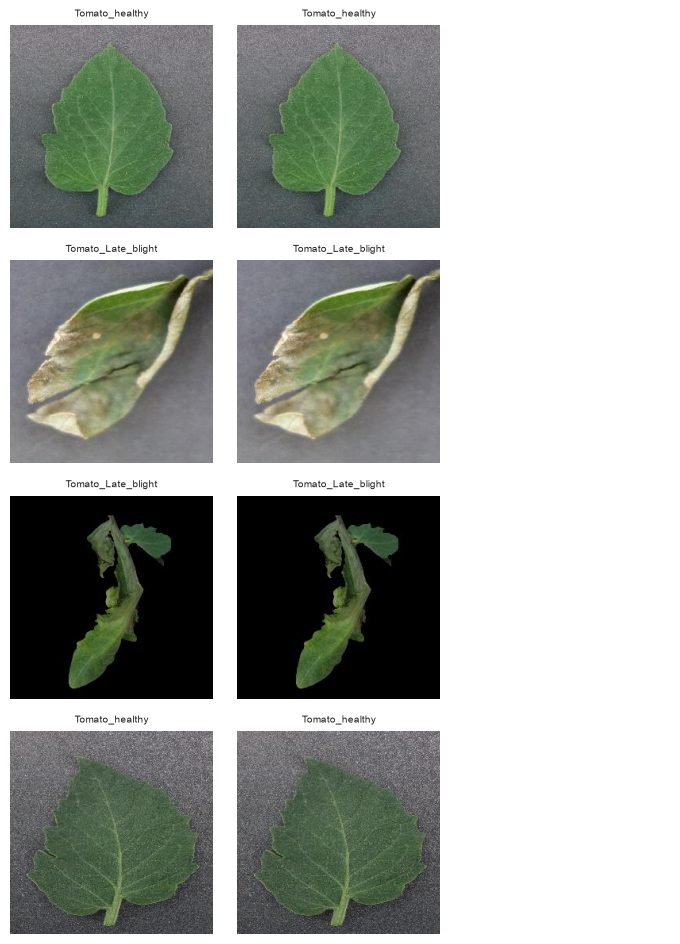

In [11]:
# Casi-duplicados: agrupamos por dHash idéntico (distancia 0) — criterio conservador y rápido.
near = df[df.duplicated("dhash", keep=False)]
grp = near.groupby("dhash")
print(f"Imágenes con dHash idéntico a otra: {len(near)} ({len(near)/len(df):.1%}) en {grp.ngroups} grupos")
print("Grupos con etiquetas distintas (posible ruido de etiquetas):", int((grp["label"].nunique() > 1).sum()))

# Ejemplos de grupos casi duplicados
examples = [g for _, g in grp if len(g) >= 2][:4]
if examples:
    fig, axes = plt.subplots(len(examples), 3, figsize=(7, 2.4 * len(examples)), squeeze=False)
    for ax in axes.ravel(): ax.axis("off")
    for r, g in enumerate(examples):
        for c, (_, row) in enumerate(g.head(3).iterrows()):
            axes[r, c].imshow(Image.open(DATA_DIR / row["relpath"]).convert("RGB"))
            axes[r, c].set_title(row["label"][:22], fontsize=7)
    plt.tight_layout(); plt.show()

**Mitigación adoptada:** el split se hace **por grupo de dHash idéntico** (todas las imágenes casi duplicadas van juntas al mismo subconjunto), de modo que un par casi idéntico no pueda quedar repartido entre train y test. Esto no elimina la fuga por hojas rotadas (dHash no es invariante a rotación), pero reduce lo más evidente; hay que mencionarlo como limitación en el informe.

## 7. Split estratificado reproducible (70 / 15 / 15)

Estratificado por clase y agrupado por hash, con semilla fija. **Todos los integrantes deben usar `splits/split.csv`** para que los resultados sean comparables.

In [12]:
from sklearn.model_selection import StratifiedGroupKFold

df["group"] = df["dhash"]

def stratified_group_split(d, test_frac, seed):
    n_splits = int(round(1 / test_frac))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rest_idx, test_idx = next(sgkf.split(d, d["y"], d["group"]))
    return d.iloc[rest_idx], d.iloc[test_idx]

trainval, test_df = stratified_group_split(df, 0.15, SEED)                 # ~15% test
train_df, val_df = stratified_group_split(trainval, 0.15 / 0.85, SEED)     # ~15% del total en val

df["split"] = "train"
df.loc[val_df.index, "split"] = "val"
df.loc[test_df.index, "split"] = "test"

out = df[["relpath", "label", "y", "plant", "condition", "healthy", "split"]]
out.to_csv(SPLITS_DIR / "split.csv", index=False)
json.dump(class_to_idx, open(SPLITS_DIR / "class_to_idx.json", "w"), indent=2)

print(df["split"].value_counts(normalize=True).round(3).to_dict())
leak = set(df[df.split == "train"].group) & set(df[df.split == "test"].group)
print("Grupos de hash compartidos entre train y test:", len(leak))

{'train': 0.714, 'val': 0.143, 'test': 0.143}
Grupos de hash compartidos entre train y test: 0


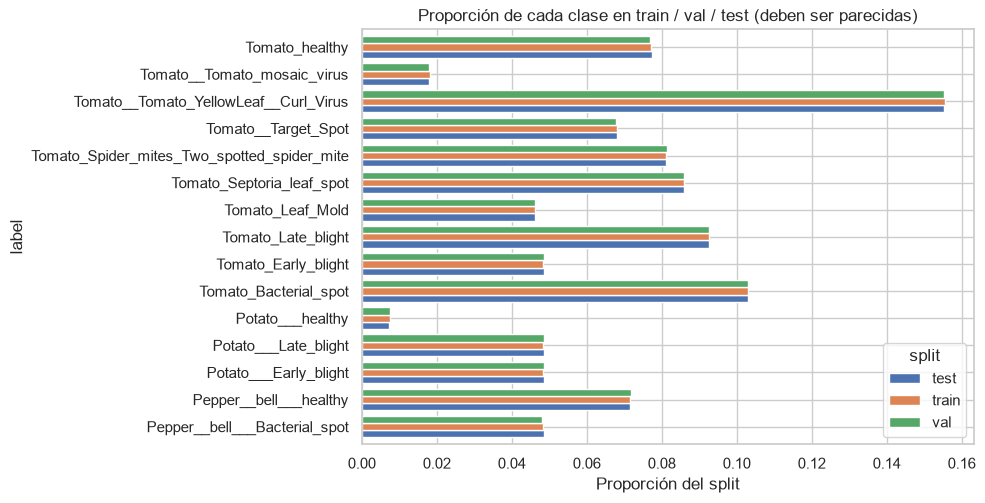

In [13]:
dist = pd.crosstab(df["label"], df["split"], normalize="columns")
fig, ax = plt.subplots(figsize=(10, 0.28 * len(dist) + 1))
dist.plot.barh(ax=ax, width=0.8); ax.set_xlabel("Proporción del split")
ax.set_title("Proporción de cada clase en train / val / test (deben ser parecidas)")
plt.tight_layout(); plt.show()

## 8. Data augmentation

Sobre CPU conviene augmentations baratas. Primero visualizamos **cada transformación por separado** sobre la misma imagen (para entender su efecto), y luego el pipeline combinado.

Criterio: las hojas no tienen orientación canónica, así que flips y rotaciones son válidos. Cambios de color moderados simulan distinta iluminación; hay que evitar tonos extremos porque el **color es una señal diagnóstica** (clorosis, manchas marrones) y no debería destruirse.

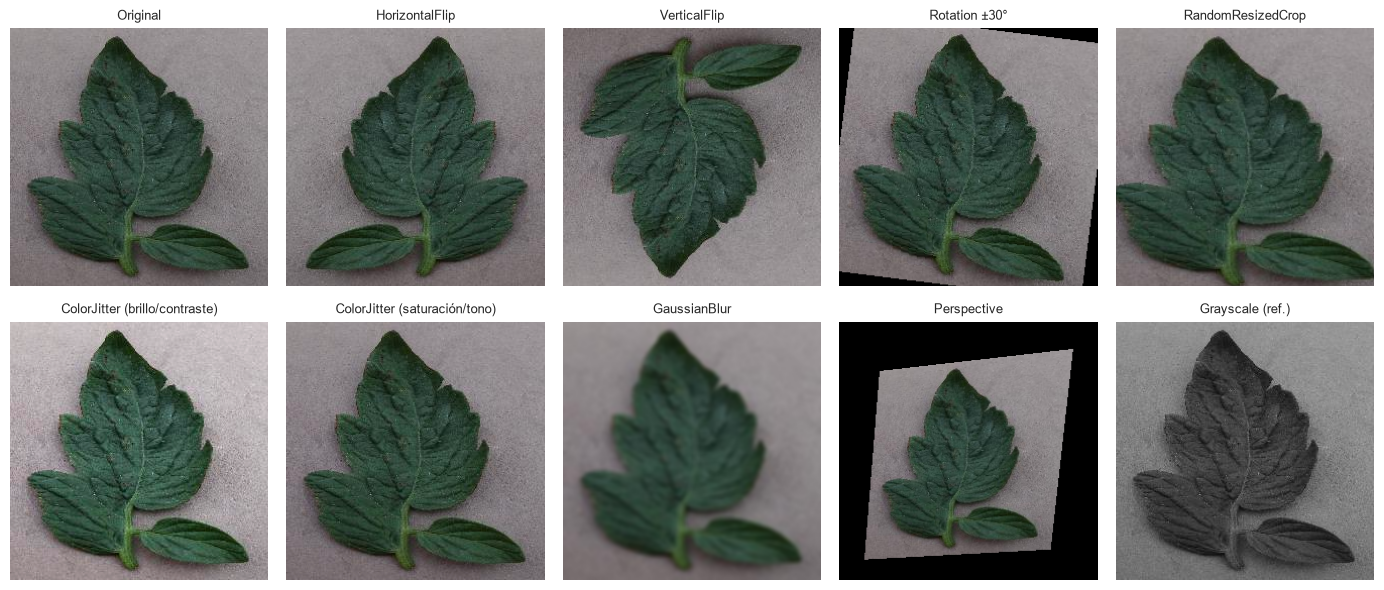

In [14]:
def load_pil(relpath):
    return Image.open(DATA_DIR / relpath).convert("RGB")

sample_row = df[df["label"] == classes[min(5, len(classes) - 1)]].iloc[0]
base = load_pil(sample_row["relpath"])

single_augs = {
    "Original": v2.Identity(),
    "HorizontalFlip": v2.RandomHorizontalFlip(p=1.0),
    "VerticalFlip": v2.RandomVerticalFlip(p=1.0),
    "Rotation ±30°": v2.RandomRotation(30),
    "RandomResizedCrop": v2.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    "ColorJitter (brillo/contraste)": v2.ColorJitter(brightness=0.4, contrast=0.4),
    "ColorJitter (saturación/tono)": v2.ColorJitter(saturation=0.4, hue=0.05),
    "GaussianBlur": v2.GaussianBlur(kernel_size=7, sigma=(1.0, 3.0)),
    "Perspective": v2.RandomPerspective(distortion_scale=0.4, p=1.0),
    "Grayscale (ref.)": v2.Grayscale(num_output_channels=3),
}

torch.manual_seed(SEED)
fig, axes = plt.subplots(2, 5, figsize=(14, 6.2))
for ax, (name, t) in zip(axes.ravel(), single_augs.items()):
    ax.imshow(t(base)); ax.set_title(name, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

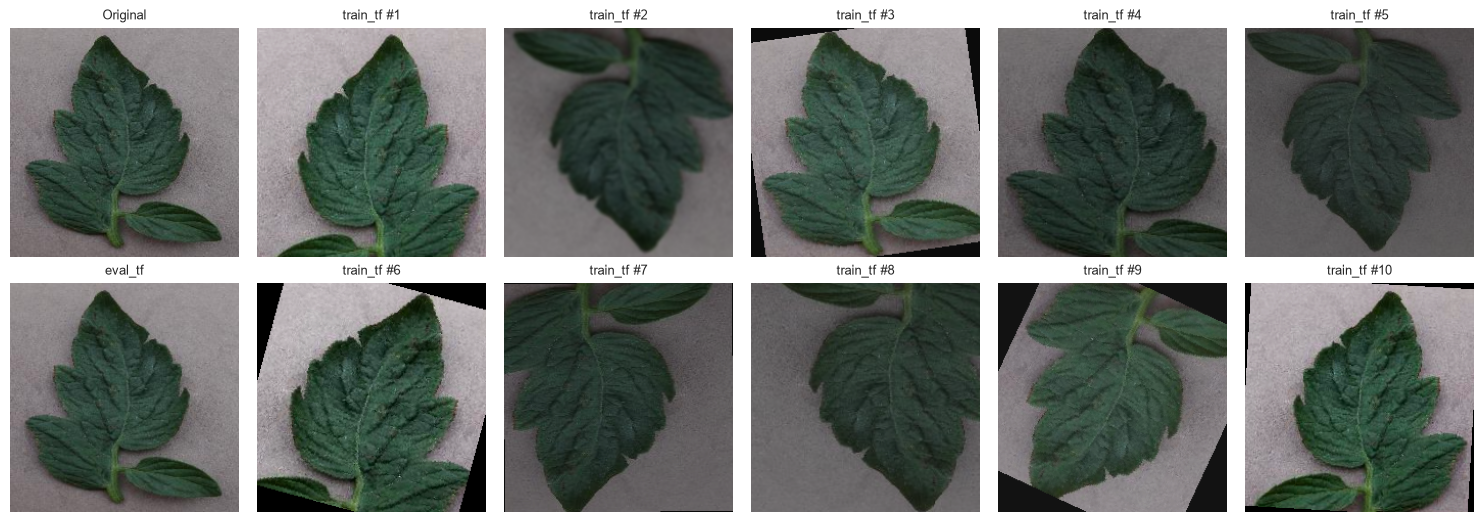

In [15]:
# Pipelines finales
train_tf = v2.Compose([
    v2.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.9, 1.1)),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomApply([v2.RandomRotation(30)], p=0.5),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.03),
    v2.RandomApply([v2.GaussianBlur(5, sigma=(0.1, 2.0))], p=0.2),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = v2.Compose([
    v2.Resize(IMG_SIZE), v2.CenterCrop(IMG_SIZE),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1); s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

torch.manual_seed(SEED)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
axes[0, 0].imshow(base.resize((IMG_SIZE, IMG_SIZE))); axes[0, 0].set_title("Original", fontsize=9)
axes[1, 0].imshow(denorm(eval_tf(base))); axes[1, 0].set_title("eval_tf", fontsize=9)
for i, ax in enumerate(list(axes[0, 1:]) + list(axes[1, 1:])):
    ax.imshow(denorm(train_tf(base))); ax.set_title(f"train_tf #{i+1}", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

**Importante:** el augmentation se aplica **solo a train**. Val y test usan `eval_tf` determinístico, de lo contrario las métricas no son comparables entre modelos.

## 9. Dataset y DataLoader de PyTorch

In [16]:
class PlantDataset(Dataset):
    def __init__(self, split_df, root=DATA_DIR, transform=None):
        self.df = split_df.reset_index(drop=True); self.root = Path(root); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(self.root / r["relpath"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, int(r["y"])

split_df = pd.read_csv(SPLITS_DIR / "split.csv")
ds = {s: PlantDataset(split_df[split_df.split == s], transform=(train_tf if s == "train" else eval_tf))
      for s in ["train", "val", "test"]}
print({s: len(d) for s, d in ds.items()})

BATCH_SIZE = 32
NUM_WORKERS = 0 if os.name == "nt" else 2       # en Windows, 0 evita problemas con multiprocessing en notebooks
train_loader = DataLoader(ds["train"], batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
xb, yb = next(iter(train_loader))
print("Batch:", tuple(xb.shape), xb.dtype, "| media %.2f, std %.2f" % (xb.mean(), xb.std()), "| etiquetas:", yb[:8].tolist())

{'train': 14740, 'val': 2949, 'test': 2949}


Batch: (32, 3, 224, 224) torch.float32 | media -0.25, std 0.92 | etiquetas: [2, 12, 5, 11, 7, 2, 13, 7]


## 10. Costo en CPU y tamaño de imagen

Medimos cuánto tarda el pipeline para estimar el tiempo de entrenamiento antes de lanzar experimentos largos.

In [17]:
import time
t0 = time.time(); n = 0
for i, (xb, yb) in enumerate(train_loader):
    n += len(xb)
    if i == 9: break
dt = time.time() - t0
print(f"{n/dt:.0f} imágenes/s solo de carga+augmentation (sin modelo)")
print(f"Época de train estimada solo en I/O: {len(ds['train'])/(n/dt)/60:.1f} min")

121 imágenes/s solo de carga+augmentation (sin modelo)
Época de train estimada solo en I/O: 2.0 min


Si el modelo en CPU resulta demasiado lento, opciones a evaluar: bajar `IMG_SIZE` a 128–160, congelar el backbone (solo entrenar la cabeza), usar arquitecturas livianas (MobileNetV3, EfficientNet-B0) o entrenar sobre un subconjunto estratificado durante la etapa de prototipado.

## 11. Resumen de decisiones y próximos pasos

| Decisión | Valor |
|---|---|
| Dataset | PlantVillage (Kaggle, 13 clases, 3 especies) |
| Split | 70/15/15 estratificado por clase y agrupado por dHash, semilla 42, en `splits/split.csv` |
| Tamaño de entrada | 224×224 |
| Normalización | Media/desvío de ImageNet |
| Augmentation (train) | RandomResizedCrop, flips, rotación, ColorJitter moderado, blur leve |
| Eval (val/test) | Resize + CenterCrop determinístico |

**Próximos notebooks:**
1. Baseline y transfer learning con varias arquitecturas preentrenadas (comparación con y sin augmentation).
2. Métricas por clase (precision, recall, F1), matriz de confusión y análisis de errores.
3. Robustez: iluminación, rotación, escala, ruido y fondo sobre el set de test.